## From theory to practice

From Chapter 2 you should have a good grasp of NumPy, JAX, and PyTorch’s torch.tensor. This is all that is needed for this chapter, and nothing else is required. From the next chapter we will progress to their higher-level APIs.

I suggest a short exercise to let you train your first differentiable model from scratch:

1. Load a toy dataset: for example, one of those contained in scikit-learn datasets module.
2. Build a linear model (for regression or classification depending on the dataset). Think about how to make the code as modular as possible: as we will see, you will need at least two functions, one for initializing the parameters of the model and one for computing the model’s predictions.
4. Train the model via gradient descent. For now you can compute the gradients manually: try to imagine how you can make also this part modular, i.e., how do you change the gradient’s computation if you want to dynamically add or remove the bias from a model?
5. Plot the loss function and the accuracy on an independent test set. If you know some standard
machine learning, you can compare the results to other supervised learning models, such as a decision tree or a k-NN, always using scikit-learn.

In [1]:
!uv pip install matplotlib scikit-learn --quiet
!uv pip install torch --quiet

## 1. Load dataset (binary classification)

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
import torch
import matplotlib.pyplot as plt

In [3]:
data = load_breast_cancer()

In [4]:
X = torch.from_numpy(data.data).float()
y = torch.from_numpy(data.target).float()

In [5]:
n = X.shape[0]  # size of the dataset
c = X.shape[1]  # features
m = len(torch.unique(y))  # classes

print(f"Size of dataset n = {n}")
print(f"Number of features c = {c}")
print(f"Classes m = {m}")

Size of dataset n = 569
Number of features c = 30
Classes m = 2


In [6]:
from sklearn.model_selection import train_test_split

# Split dataset 80% train / 20% test for step 4
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Feature normalization

In [7]:
mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)

X_train = (X_train - mean) / (std + 1e-8)
X_test = (X_test - mean) / (std + 1e-8)  # Use train mean and std to normalize test

## 2. Binary Logistic Regression model

In [8]:
class BinaryLogisticRegression:

    def __init__(self, c, use_bias=True):
        # We don't use b, we add 1 to the features w ~ (c + 1)
        n_features = c + 1 if use_bias else c
        self.w = torch.normal(0, 0.01, size=(n_features,))
        self.use_bias = use_bias

    @staticmethod
    def _augment(X):
        return torch.column_stack((X, torch.ones(X.size(0))))

    @staticmethod
    def sigmoid(s):
        return 1.0 / (1.0 + torch.exp(-s))

    def grad(self, X, y):
        if self.use_bias:
            X = self._augment(X)
        return (self.sigmoid(X @ self.w) - y) @ X

    def forward(self, X):
        if self.use_bias:
            X = self._augment(X)
        return self.sigmoid(X @ self.w)

In [9]:
def binary_cross_entropy(y, y_pred):
    return torch.mean(-y * torch.log(y_pred) - (1.0 - y) * torch.log(1.0 - y_pred))

## 3. Train

The book doesn't derive the gradient for the logistic regression. The softmax function makes it a bit complicated. So we use torch's autograd for gradient descent.

In [10]:
learning_rate = 1e-6
momentum = 0.9
epochs = 15000

In [11]:
blr_model = BinaryLogisticRegression(c)
gradw = torch.zeros_like(blr_model.w)
test_loss = []
test_acc = []

In [12]:
for epoch in range(epochs):
    y_pred = blr_model.forward(X_train)
    loss = binary_cross_entropy(y_train, y_pred)
    test_loss.append(binary_cross_entropy(y_test, blr_model.forward(X_test)))
    test_acc.append(((blr_model.forward(X_test) > 0.5) == (y_test > 0.5)).float().mean())
    # Compute gradient and update weights
    gradw = -learning_rate * blr_model.grad(X_train, y_train) + momentum * gradw
    blr_model.w += gradw
    # Check for convergence
    if torch.linalg.vector_norm(gradw) < 1e-5:
        print(f"Converged at epoch {epoch + 1}")
        break
    # print(f"Epoch {epoch + 1} - loss: {loss}")

## 4. Test loss and accuracy

In [13]:
pred = blr_model.forward(X_test) > 0.5

In [14]:
(pred == (y_test > 0.5)).float().mean()

tensor(0.9737)

kNN is very sensitive to the `n_neighbors` hyperparameter.

In [15]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test) > 0.5
(knn_pred == (y_test > 0.5)).float().mean()

tensor(0.9825)

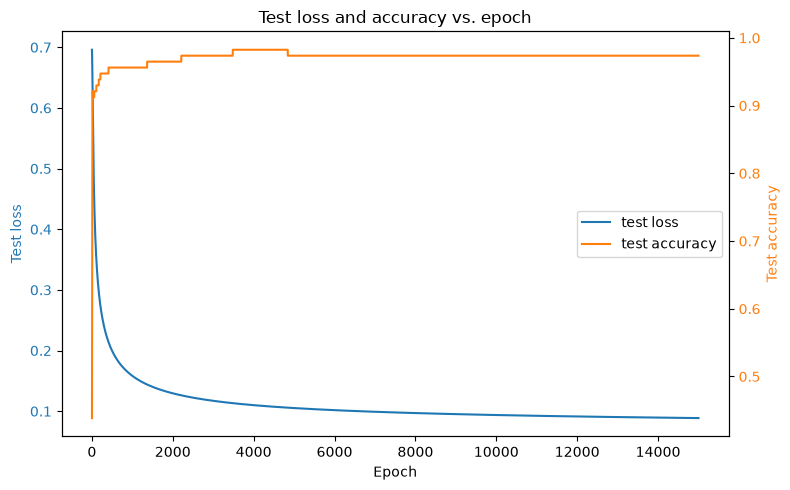

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Loss on the left axis
ax1.plot(range(1, len(test_loss) + 1), [l.item() for l in test_loss], color="tab:blue", label="test loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Test loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Accuracy on the right axis (different scale, so a twin axis)
ax2 = ax1.twinx()
ax2.plot(range(1, len(test_acc) + 1), [a.item() if torch.is_tensor(a) else a for a in test_acc],
         color="tab:orange", label="test accuracy")
ax2.set_ylabel("Test accuracy", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Test loss and accuracy vs. epoch")
fig.tight_layout()

# Combined legend (twin axes keep separate legends, so merge them)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.show()

In [17]:
# EOF